In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import librosa
import soundfile as sf
from tqdm import tqdm
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

d:\Downloads\anaconda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
d:\Downloads\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


# preparation

In [74]:
path = "dataset"

## func

In [3]:
MAX_DURATION = 12

def extract_features(audio_path):
    y, sr = librosa.load(audio_path, sr=None, duration=MAX_DURATION)

    mels = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=20)
    mels_db = librosa.power_to_db(mels, ref=np.max)

    zcr = librosa.feature.zero_crossing_rate(y)

    return np.hstack([
        np.mean(mels_db, axis=1),
        np.std(mels_db, axis=1),
        np.mean(zcr, axis=1),
        np.std(zcr, axis=1)
    ])

In [4]:
SEGMENT_DURATION = 12
MIN_LONG_AUDIO = 60

def split_long_audio_files(source_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    class_dirs = [
        d for d in os.listdir(source_dir)
        if os.path.isdir(os.path.join(source_dir, d))
    ]

    for class_label in tqdm(class_dirs, desc="Splitting long audio"):
        source_class_path = os.path.join(source_dir, class_label)
        output_class_path = os.path.join(output_dir, class_label)
        os.makedirs(output_class_path, exist_ok=True)

        files = [
            f for f in os.listdir(source_class_path)
            if f.lower().endswith(('.wav', '.mp3'))
        ]

        for file in files:
            file_path = os.path.join(source_class_path, file)

            try:
                y, sr = librosa.load(file_path, sr=None)
                duration = librosa.get_duration(y=y, sr=sr)

                base_name = file.rsplit('.', 1)[0]

                if duration <= MIN_LONG_AUDIO:
                    save_path = os.path.join(output_class_path, f"{base_name}.wav")
                    if not os.path.exists(save_path):
                        sf.write(save_path, y, sr)
                    continue

                segment_samples = SEGMENT_DURATION * sr

                for i, start in enumerate(range(0, len(y), segment_samples)):
                    segment = y[start:start + segment_samples]

                    if len(segment) < sr:
                        continue

                    save_path = os.path.join(
                        output_class_path,
                        f"{base_name}_part_{i + 1}.wav"
                    )

                    sf.write(save_path, segment, sr)

            except Exception as e:
                print(f"Помилка під час обробки {file_path}: {e}")

In [5]:
def process_emotion_folders(audio_path):
    X, y = [], []
    
    emotion_dirs = [d for d in os.listdir(audio_path) if os.path.isdir(os.path.join(audio_path, d))]

    for emotion_label in tqdm(emotion_dirs, desc="Processing sounds"):
        emotion_path = os.path.join(audio_path, emotion_label)
        
        files = [f for f in os.listdir(emotion_path) if f.lower().endswith(('.wav', '.mp3'))]
        
        for file in files:
            file_path = os.path.join(emotion_path, file)
            
            features = extract_features(file_path)
            if features is not None:
                X.append(features)
                y.append(emotion_label)
                
    return np.array(X), np.array(y)

In [6]:
# def convert_audio_to_images(source_dir, target_dir, n_mels=20):

#     os.makedirs(target_dir, exist_ok=True)
#     emotion_dirs = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

#     for emotion_label in tqdm(emotion_dirs, desc="processing emotions"):
#         source_emotion_path = os.path.join(source_dir, emotion_label)
        
#         target_emotion_path = os.path.join(target_dir, emotion_label)
#         os.makedirs(target_emotion_path, exist_ok=True)
        
#         files = [f for f in os.listdir(source_emotion_path) if f.lower().endswith(('.wav', '.mp3'))]
    
#         for file in files:
#             file_path = os.path.join(source_emotion_path, file)
#             new_file_name = file.rsplit('.', 1)[0] + '.png'
#             save_path = os.path.join(target_emotion_path, new_file_name)
            
#             y, sr = librosa.load(file_path, sr=22050)
                
#             S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
#             S_dB = librosa.power_to_db(S, ref=np.max)

#             fig, ax = plt.subplots(figsize=(2, 2))
#             ax.axis('off')
#             fig.subplots_adjust(left=0, right=1, bottom=0, top=1) 

#             librosa.display.specshow(S_dB, sr=sr, cmap='inferno', ax=ax)

#             fig.savefig(save_path, format='png', dpi=100)
#             plt.close(fig)

In [146]:
titles = ['без нормалізації', 'нормалізація по Recall', 'нормалізація по Precision']
def plot_cm(models, X, y_true):
    if not isinstance(models, (list, tuple)):
        models = [models]

    n_models = len(models)

    fig, axs = plt.subplots(n_models, 3, figsize=(20, 5 * n_models))

    if n_models == 1:
        axs = np.array([axs])

    for i, model in enumerate(models):
        y_pred = model.predict(X)
        cm = confusion_matrix(y_true, y_pred)
        cm_recall = confusion_matrix(
            y_true,
            y_pred,
            normalize='true'
        )
        cm_precision = confusion_matrix(
            y_true,
            y_pred,
            normalize='pred'
        )

        matrices = [cm, cm_recall, cm_precision]

        for j, matrix in enumerate(matrices):
            sns.heatmap(
                matrix,
                annot=True,
                fmt=['d', '.2f', '.2f'][j],
                cmap='crest',
                ax=axs[i, j]
            )

            axs[i, j].set_title(titles[j])

            axs[i, j].set_xlabel('predicted label')
            axs[i, j].set_ylabel('true label')
            axs[i, j].tick_params(axis='y', labelrotation=0)

    plt.show()

In [8]:
def scatter (X_list, y, titles=None):
    n = len(X_list)
    f, axs = plt.subplots(1, n, figsize = (8 * n, 6))

    if n == 1:
        axs = [axs]
        
    for i in range(n):
        sns.scatterplot(
            x = X_list[i][:, 0], 
            y = X_list[i][:, 1], 
            hue = y,        
            palette = 'mako',
            ax = axs[i],
            alpha = 0.7
        )
        
        if titles and i < len(titles):
            axs[i].set_title(titles[i])
            
    plt.tight_layout()    
    plt.show()

## eda

In [76]:
audio_data = []
for class_name in os.listdir(path):
    folder = os.path.join(path, class_name)
    for file_name in os.listdir(folder):
        if file_name.endswith(".mp3"):
            audio_data.append([class_name, file_name, os.path.join(folder, file_name)])
df_audio = pd.DataFrame(
    audio_data,
    columns=["class", "file_name", "file_path"]
)
df_audio.head(15)

,class,file_name,file_path
0,air vehicles,Aircraft_-_Auster_aircraft__Landing_.mp3,dataset\air vehicles\Aircraft_-_Auster_aircraf...
1,air vehicles,Aircraft_-_Auster_aircraft__Landing__hits_soft...,dataset\air vehicles\Aircraft_-_Auster_aircraf...
2,air vehicles,Aircraft_-_Auster_aircraft__Passes_overhead.mp3,dataset\air vehicles\Aircraft_-_Auster_aircraf...
3,air vehicles,Aircraft_-_Auster_aircraft__Passes_overhead_.mp3,dataset\air vehicles\Aircraft_-_Auster_aircraf...
4,air vehicles,Aircraft_-_A_single_jet_707B_aircraft_passing_...,dataset\air vehicles\Aircraft_-_A_single_jet_7...
5,air vehicles,Aircraft_-_A_single_jet_707B_aircraft__start__...,dataset\air vehicles\Aircraft_-_A_single_jet_7...
6,air vehicles,Aircraft_-_Exterior__landing___Starfighter__Si...,dataset\air vehicles\Aircraft_-_Exterior__land...
7,air vehicles,Aircraft_-_Flying_Fortress__ticking_over___Wor...,dataset\air vehicles\Aircraft_-_Flying_Fortres...
8,air vehicles,Aircraft_-_Hawker_Harrier__exterior__start___r...,dataset\air vehicles\Aircraft_-_Hawker_Harrier...
9,air vehicles,Aircraft_-_Hercules__Aircraft__landing___taxin...,dataset\air vehicles\Aircraft_-_Hercules__Airc...


In [10]:
df_audio.shape

(284, 3)

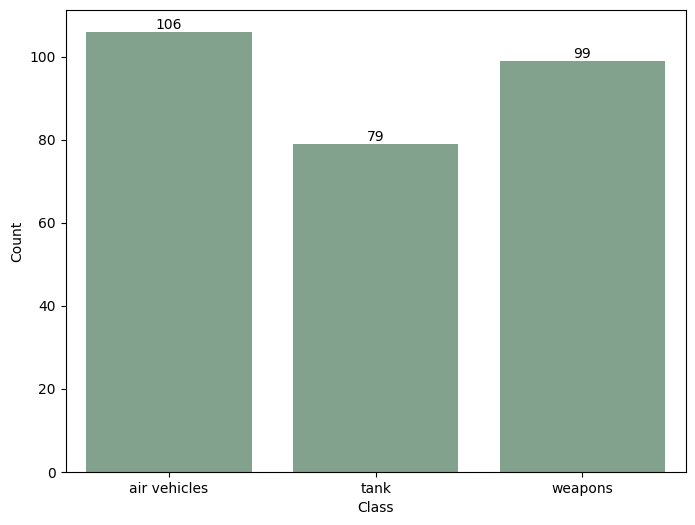

In [114]:
f, ax = plt.subplots(1, 1, figsize=(8,6))

sns.countplot(data=df_audio, x="class", color='#7DA78C', ax=ax)

for container in ax.containers:
    ax.bar_label(container)

plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [12]:
# тривалість кожного аудіофайлу у нову колонку
durations = []
for file_path in df_audio["file_path"]:
    y, sr = librosa.load(file_path,
                         sr=None # залишити оригінальну частоту аудіо
                         )
    duration = librosa.get_duration(y=y, # аудіосигнал (масив чисел)
                                    sr=sr # sample rate (частота)
                                    )
    durations.append(duration)
df_audio["duration"] = durations

d:\Downloads\anaconda\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
d:\Downloads\anaconda\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,


In [13]:
df_audio.groupby("class")["duration"].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
air vehicles,106.0,109.640474,95.370149,10.240000,40.373776,76.059773,143.151531,393.795147
tank,79.0,110.078606,103.381699,7.367596,37.070000,70.959637,154.826667,480.762268
weapons,99.0,63.888234,64.225453,2.566667,12.810057,41.200000,105.845590,339.057143


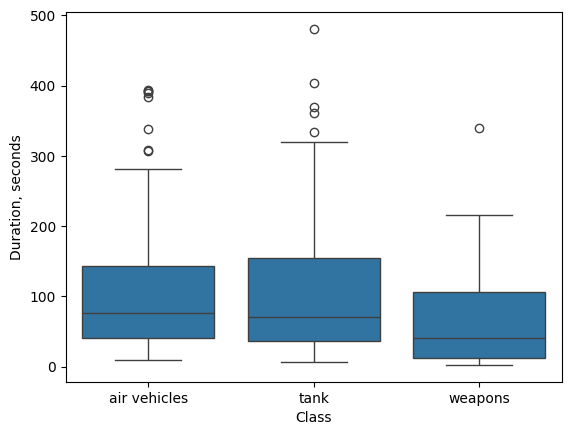

In [14]:
sns.boxplot(data=df_audio, x="class", y="duration")
plt.xlabel("Class")
plt.ylabel("Duration, seconds")
plt.show()

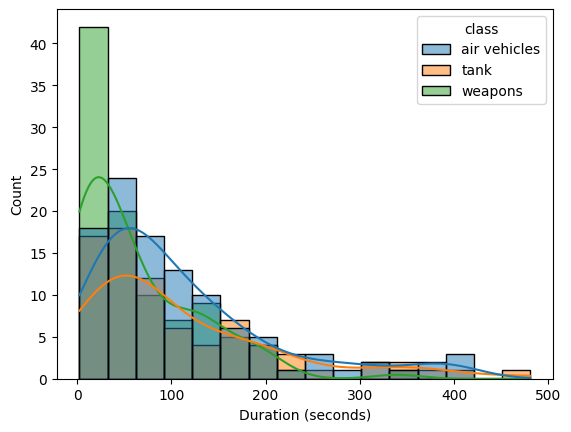

In [15]:
sns.histplot(data=df_audio, x="duration", hue="class", kde=True)
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()

In [16]:
print(df_audio.columns)

Index(['class', 'file_name', 'file_path', 'duration'], dtype='str')


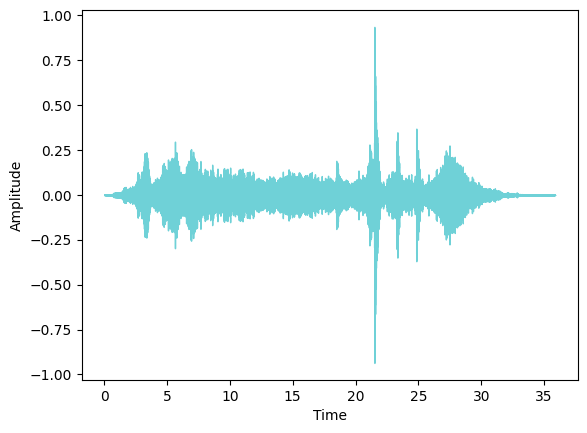

In [140]:
y, sr = librosa.load(df_audio["file_path"].iloc[0], sr=None)
librosa.display.waveshow(y, sr=sr, color="#6FD1D7")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

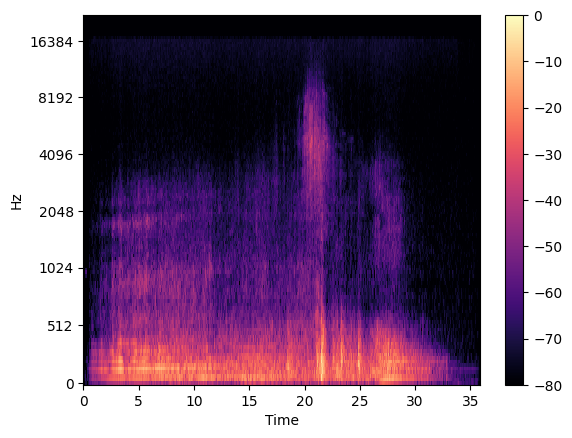

In [18]:
mel = librosa.feature.melspectrogram(y=y, sr=sr)
mel_db = librosa.power_to_db(mel, ref=np.max)
librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar()
plt.show()

## preprocess

In [19]:
path = "dataset"

split_long_audio_files(
    source_dir=path,
    output_dir="dataset_processed"
)

path = "dataset_processed"

Splitting long audio: 100%|██████████| 3/3 [01:12<00:00, 24.11s/it]


In [20]:
# output_folder = "spectrograms" 
# convert_audio_to_images(path, output_folder)

In [21]:
X_raw, y_raw = process_emotion_folders(path)

Processing sounds: 100%|██████████| 3/3 [01:41<00:00, 33.71s/it]


In [22]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=90, stratify=y_raw)

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

In [24]:
X_train_df = pd.DataFrame(X_train)
y_train_df = pd.DataFrame(y_train)
X_test_df = pd.DataFrame(X_test)
y_test_df = pd.DataFrame(y_test)

In [25]:
feature_names = ([f'mel_mean_{i}' for i in range(20)] + 
                 [f'mel_std_{i}' for i in range(20)] + 
                 ['zcr_mean', 'zcr_std'])

X_train_df.columns = feature_names

In [26]:
X_test_df.columns = X_train_df.columns

## vector eda

In [27]:
X_train_df.head()

,mel_mean_0,mel_mean_1,mel_mean_2,mel_mean_3,mel_mean_4,mel_mean_5,mel_mean_6,mel_mean_7,mel_mean_8,mel_mean_9,...,mel_std_12,mel_std_13,mel_std_14,mel_std_15,mel_std_16,mel_std_17,mel_std_18,mel_std_19,zcr_mean,zcr_std
0,0.189513,1.219052,1.362736,1.473780,1.575007,1.541335,1.616844,1.539902,1.376981,1.133900,...,-0.528098,-0.499208,-0.492790,-0.445881,-0.507632,-0.455621,-0.314215,-0.206791,-0.062278,-0.326575
1,0.564231,0.732278,0.799382,0.780951,0.914938,0.870043,0.791326,0.691158,0.542356,0.408544,...,-0.330193,-0.599962,-0.821651,-0.834842,-0.716022,-0.441294,-0.474299,-0.182789,-0.318024,-0.377458
2,0.860933,0.823397,1.098665,1.018807,0.660048,0.841744,0.546489,0.384105,0.286727,0.275080,...,-0.600543,-0.496152,-0.335203,-0.111918,0.152043,0.450303,0.987217,-0.394698,-0.422105,-0.449769
3,-0.672674,0.190116,0.371647,0.573906,0.898043,0.971070,0.830806,0.798124,0.853493,0.863617,...,2.067944,1.995927,1.976669,1.938989,1.576005,0.646952,0.015564,-0.620561,0.110619,-0.265474
4,0.638195,1.025106,1.031596,1.012340,1.185988,1.200016,1.426323,1.458571,1.474328,1.594061,...,-0.090829,-0.025526,0.094202,0.189965,0.105337,-0.535889,-0.456757,-0.143037,0.122937,-0.216774


In [28]:
X_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 42 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   mel_mean_0   1671 non-null   float64
 1   mel_mean_1   1671 non-null   float64
 2   mel_mean_2   1671 non-null   float64
 3   mel_mean_3   1671 non-null   float64
 4   mel_mean_4   1671 non-null   float64
 5   mel_mean_5   1671 non-null   float64
 6   mel_mean_6   1671 non-null   float64
 7   mel_mean_7   1671 non-null   float64
 8   mel_mean_8   1671 non-null   float64
 9   mel_mean_9   1671 non-null   float64
 10  mel_mean_10  1671 non-null   float64
 11  mel_mean_11  1671 non-null   float64
 12  mel_mean_12  1671 non-null   float64
 13  mel_mean_13  1671 non-null   float64
 14  mel_mean_14  1671 non-null   float64
 15  mel_mean_15  1671 non-null   float64
 16  mel_mean_16  1671 non-null   float64
 17  mel_mean_17  1671 non-null   float64
 18  mel_mean_18  1671 non-null   float64
 19  mel_mean_19  1671

In [29]:
X_train_df.duplicated().sum()

0

In [30]:
X_train_df.describe()

,mel_mean_0,mel_mean_1,mel_mean_2,mel_mean_3,mel_mean_4,mel_mean_5,mel_mean_6,mel_mean_7,mel_mean_8,mel_mean_9,...,mel_std_12,mel_std_13,mel_std_14,mel_std_15,mel_std_16,mel_std_17,mel_std_18,mel_std_19,zcr_mean,zcr_std
count,1.671000e+03,1.671000e+03,1.671000e+03,1.671000e+03,1.671000e+03,1.671000e+03,1.671000e+03,1.671000e+03,1.671000e+03,1.671000e+03,...,1.671000e+03,1.671000e+03,1.671000e+03,1.671000e+03,1.671000e+03,1.671000e+03,1.671000e+03,1.671000e+03,1.671000e+03,1.671000e+03
mean,6.378301e-17,-7.228741e-17,-1.116203e-16,-1.275660e-17,-1.254399e-16,-2.987171e-16,2.678886e-16,-1.190616e-16,1.860338e-16,-2.445015e-17,...,-9.514299e-17,2.870235e-17,6.431454e-17,-1.126833e-16,5.315251e-18,5.740471e-17,-2.019795e-17,-4.677421e-17,7.712429e-16,5.623535e-16
std,1.000299e+00,1.000299e+00,1.000299e+00,1.000299e+00,1.000299e+00,1.000299e+00,1.000299e+00,1.000299e+00,1.000299e+00,1.000299e+00,...,1.000299e+00,1.000299e+00,1.000299e+00,1.000299e+00,1.000299e+00,1.000299e+00,1.000299e+00,1.000299e+00,1.000299e+00,1.000299e+00
min,-5.018165e+00,-5.043149e+00,-4.583590e+00,-4.297894e+00,-4.153965e+00,-3.847805e+00,-3.647299e+00,-3.477805e+00,-3.242419e+00,-2.990867e+00,...,-1.087948e+00,-1.036361e+00,-1.026047e+00,-1.056068e+00,-1.007058e+00,-9.291753e-01,-9.832798e-01,-8.811562e-01,-6.474550e-01,-5.603668e-01
25%,-5.083438e-01,-5.322658e-01,-5.841110e-01,-6.154612e-01,-6.271610e-01,-6.566169e-01,-6.217193e-01,-6.187375e-01,-6.568300e-01,-7.094735e-01,...,-7.423750e-01,-7.325153e-01,-7.086467e-01,-6.699602e-01,-6.321711e-01,-5.875266e-01,-5.265041e-01,-5.246723e-01,-4.679310e-01,-4.406675e-01
50%,2.743460e-01,1.820616e-01,1.646792e-01,1.550557e-01,1.369612e-01,1.464007e-01,9.077873e-02,8.360608e-02,8.109687e-02,4.144200e-02,...,-3.082894e-01,-3.422663e-01,-3.604967e-01,-3.734019e-01,-3.986744e-01,-3.965213e-01,-3.096708e-01,-2.686525e-01,-3.512144e-01,-3.425717e-01
75%,7.572815e-01,7.547268e-01,7.542978e-01,7.098038e-01,7.241472e-01,7.356360e-01,7.235657e-01,7.114153e-01,7.312857e-01,7.330601e-01,...,3.781334e-01,3.188388e-01,2.868146e-01,2.879057e-01,2.364248e-01,1.410816e-01,1.157909e-01,1.759079e-01,-3.271375e-02,-4.431079e-03
max,1.338807e+00,1.628235e+00,2.036215e+00,2.182338e+00,2.438144e+00,2.599092e+00,2.557404e+00,2.648532e+00,2.827437e+00,2.784357e+00,...,4.979299e+00,5.061428e+00,5.183809e+00,4.963105e+00,5.338693e+00,5.994292e+00,8.492153e+00,9.091606e+00,6.223950e+00,5.787382e+00


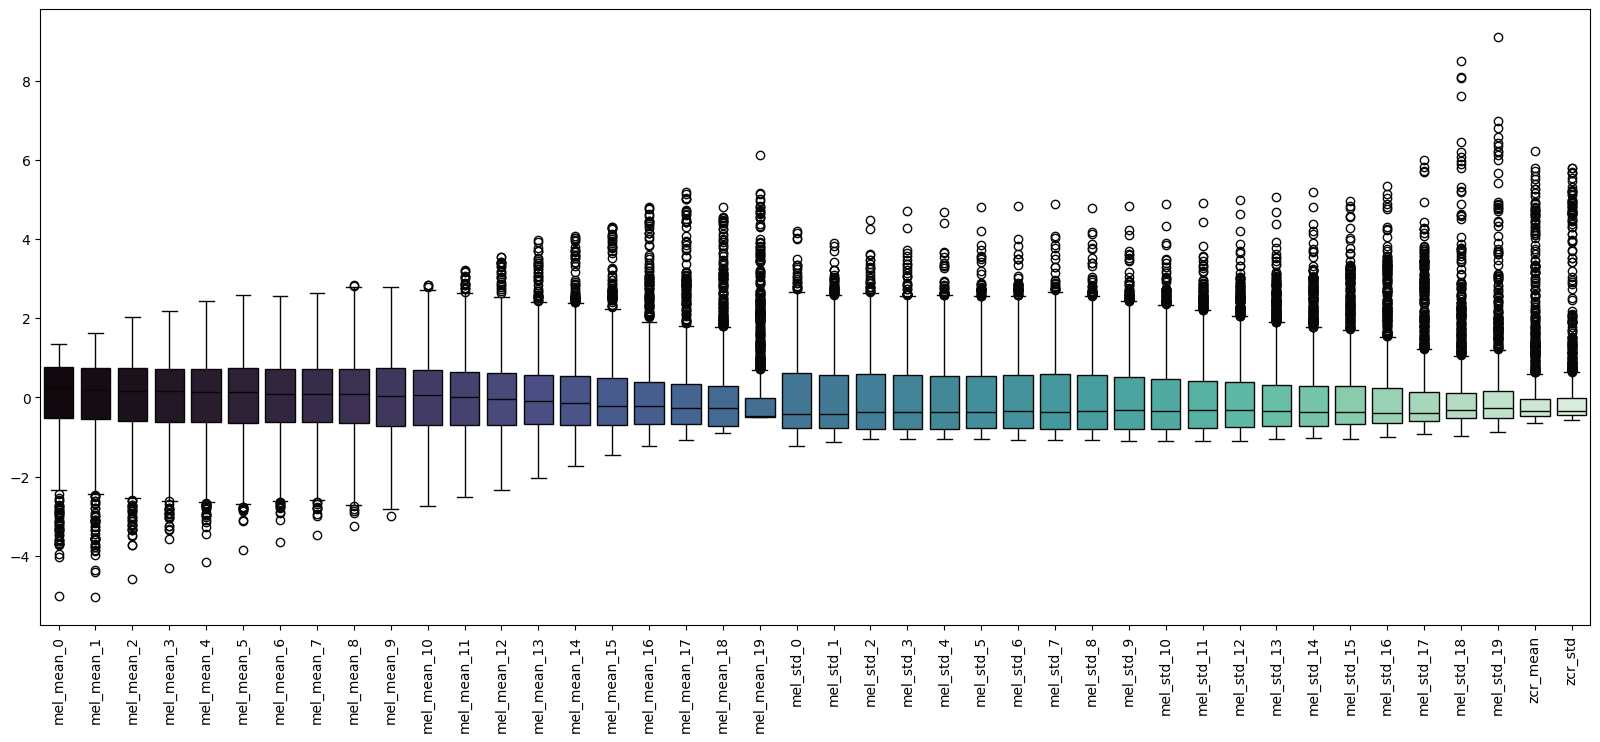

In [119]:
f, ax = plt.subplots(1,1,  figsize=(20, 8))

sns.boxplot(
    data=X_train_df, 
    orient="v", 
    palette="mako",
    ax = ax
    )

plt.xticks(rotation=90)
plt.show()

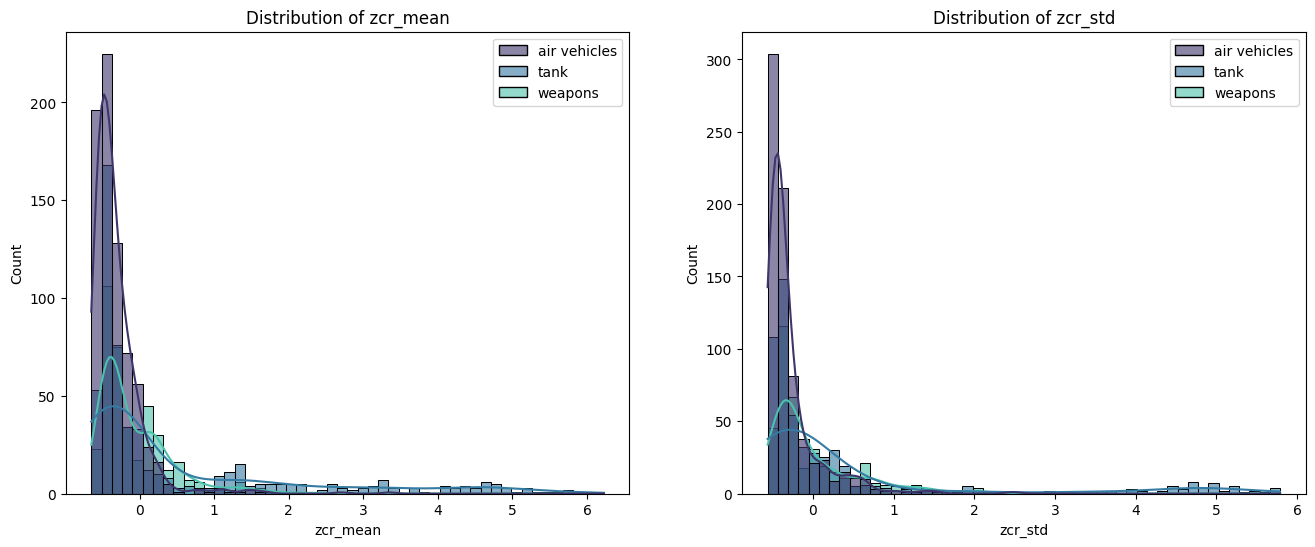

In [90]:
f, axs = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(
    data=X_train_df,
    x='zcr_mean', 
    hue=y_train,
    bins=50, 
    kde=True, 
    ax=axs[0], 
    palette='mako', 
    alpha=0.6
    )

axs[0].set_title("Distribution of zcr_mean")

sns.histplot(
    data=X_train_df,
    x='zcr_std', 
    hue=y_train,
    bins=50, 
    kde=True, 
    ax=axs[1], 
    palette='mako', 
    alpha=0.6
    )

axs[1].set_title("Distribution of zcr_std")
plt.show()

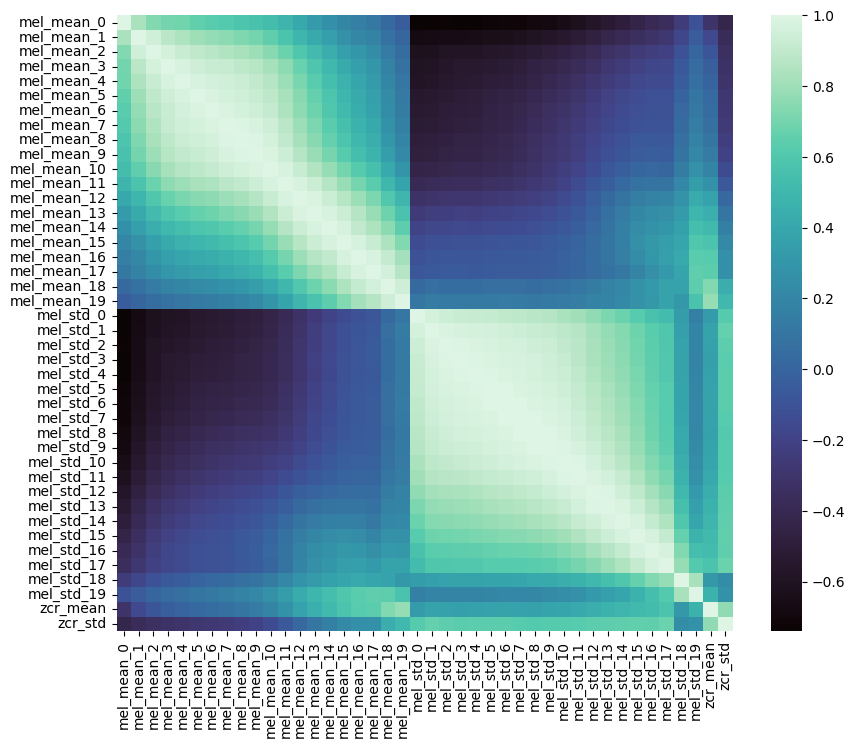

In [33]:
f, ax = plt.subplots(1, 1, figsize=(10, 8))

sns.heatmap(
    X_train_df.corr(), 
    cmap="mako", 
    square=True,
    ax=ax
    )

plt.show()

In [106]:
y_train_df

,0
0,air vehicles
1,air vehicles
2,tank
3,weapons
4,air vehicles
...,...
1666,weapons
1667,air vehicles
1668,tank
1669,tank


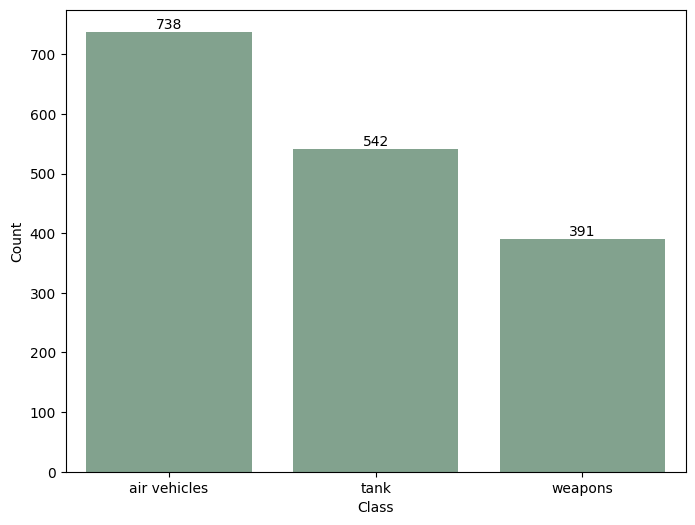

In [113]:
f, ax = plt.subplots(1, 1, figsize=(8,6))
sns.countplot(
    x = y_train_df.squeeze(), 
    color = '#7DA78C',
    ax = ax
    )

for container in ax.containers:
    ax.bar_label(container)

plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

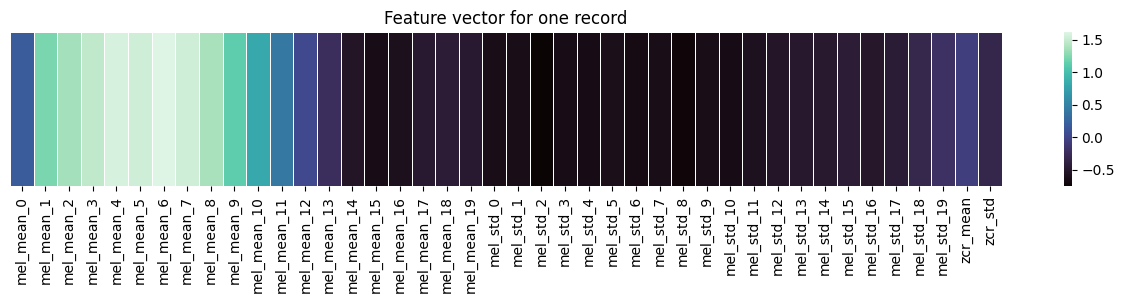

In [136]:
f, ax = plt.subplots(1,1, figsize=(16, 2)) 
sns.heatmap(
    X_train_df.iloc[[0]], 
    cmap="mako", 
    cbar=True, 
    yticklabels=False,
    linewidths=0.5,
    ax = ax
)

ax.set_title("Feature vector for one record", fontsize=12)
plt.show()

### visual with dimensionality reduction

In [34]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X_train_df)

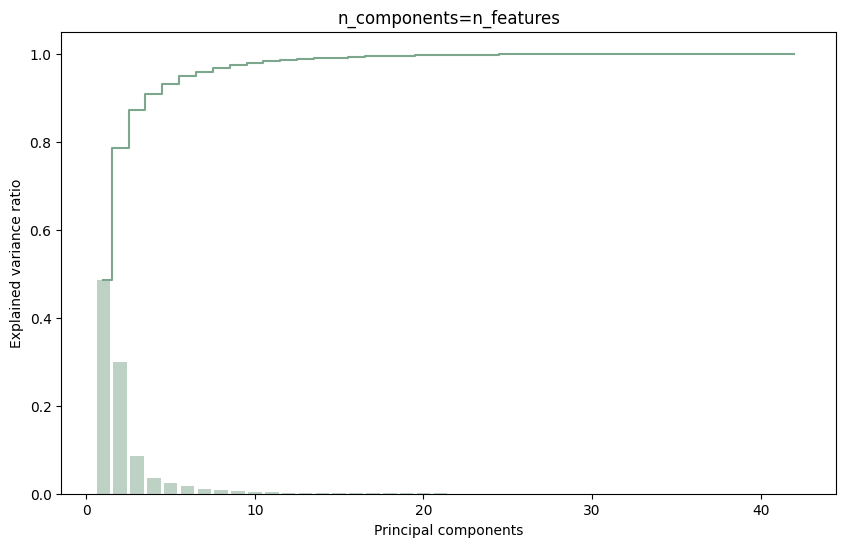

In [35]:
n_features = X_train_df.shape[1]

pca_n = PCA(n_components=n_features)
x_pca_n = pca_n.fit_transform(X_train_df)

exp_var = pca_n.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

f, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.bar(
    range(1, len(exp_var) + 1), 
    exp_var, 
    alpha=0.5, 
    align='center',
    color = '#7DA78C'
    )

ax.step(
    range(1, len(cum_var) + 1), 
    cum_var, 
    where='mid',
    color = '#7DA78C'
    )

ax.set(title='n_components=n_features', xlabel='Principal components', ylabel='Explained variance ratio')

plt.show()

Аналіз PCA показав, що 90% варіативності датасету несуть у собі 4-5 ознак. Однак ця домінуюча дисперсія не містить інформації для розділення класів. Важливий для класифікації сигнал має малу дисперсію і втрачається при зменшенні розмірності, що пояснює падіння точності нелінійних моделей.

In [36]:
isomap = Isomap(
    n_components=2,
    n_neighbors=50,
    n_jobs=2
)

x_isomap = isomap.fit_transform(X_train_df)

d:\Downloads\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\Downloads\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "d:\Downloads\anaconda\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Downloads\anaconda\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\Downloads\anaconda\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable

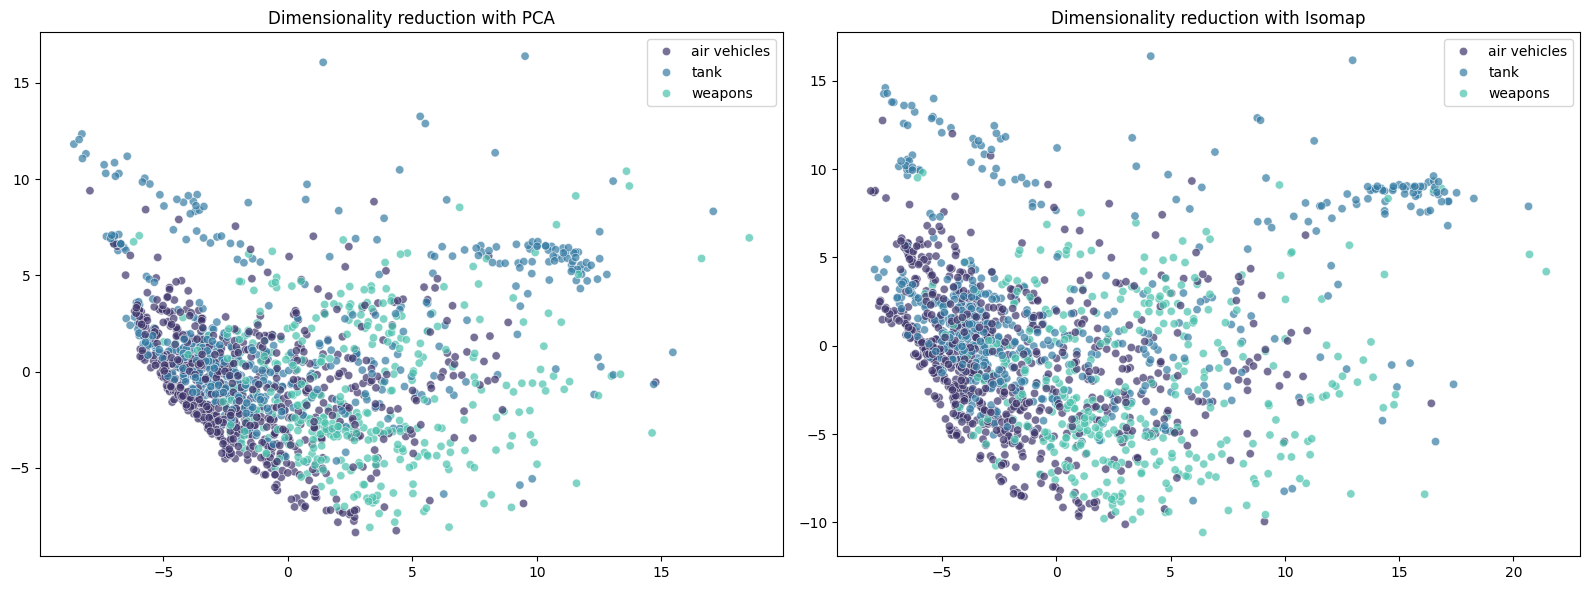

In [37]:
scatter([x_pca, x_isomap], y_train, ['Dimensionality reduction with PCA', 'Dimensionality reduction with Isomap'])

# model training

## log regression

In [38]:
params_logreg = {
    "C": [0.01, 0.1, 1, 10, 100],
    "class_weight": [None, "balanced"]
}

In [39]:
grid_logreg = GridSearchCV(
    LogisticRegression(
        max_iter=3000,
        random_state=25
    ),
    params_logreg,
    cv=5,
    scoring="f1_macro"
)

In [40]:
grid_logreg.fit(X_train_df, y_train_df)

d:\Downloads\anaconda\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\Downloads\anaconda\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\Downloads\anaconda\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\Downloads\anaconda\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=25)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also display

In [41]:
y_pred_log = grid_logreg.predict(X_test_df)

In [42]:
best_logreg = grid_logreg.best_estimator_

In [43]:
print(classification_report(y_test_df,y_pred_log))

              precision    recall  f1-score   support

air vehicles       0.78      0.77      0.77       185
        tank       0.76      0.67      0.71       136
     weapons       0.69      0.84      0.76        97

    accuracy                           0.75       418
   macro avg       0.75      0.76      0.75       418
weighted avg       0.75      0.75      0.75       418



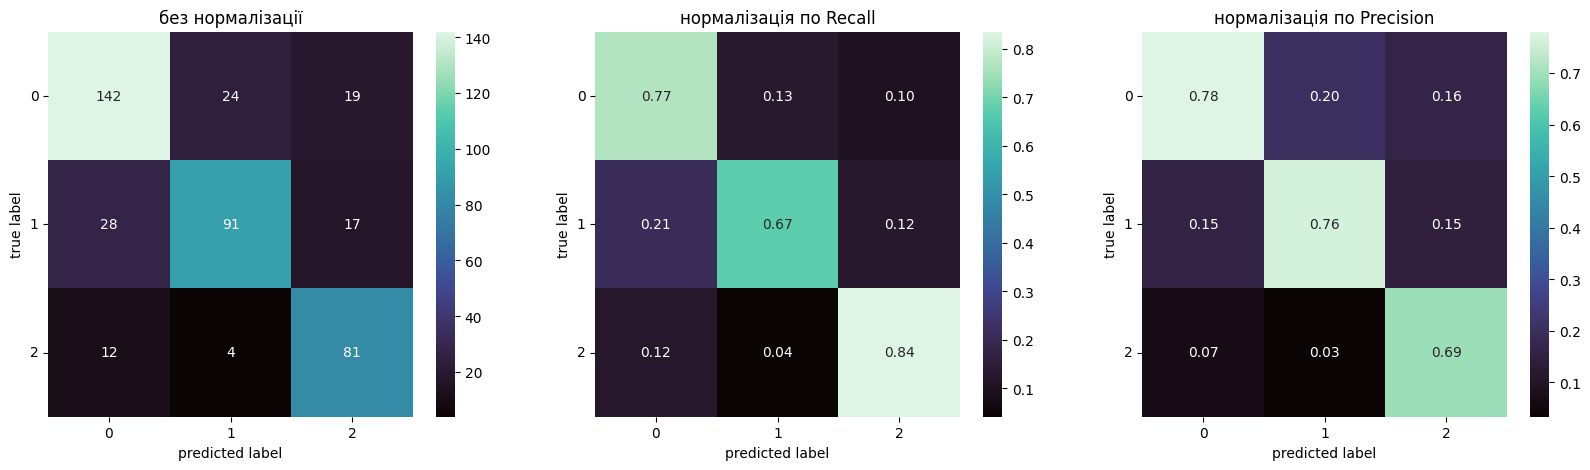

In [145]:
plot_cm(grid_logreg, X_test_df, y_test_df)

## svm

### OneVSOne

In [45]:
ovo = OneVsOneClassifier(SVC(class_weight='balanced', random_state=90))

param_random_ovo = {
    "estimator__C": [0.1, 1, 10],
    "estimator__kernel": ['linear', 'rbf', 'poly'],
    "estimator__gamma": ['scale', 'auto']
}

In [46]:
random_ovo = RandomizedSearchCV(ovo, param_random_ovo, cv=10, random_state=90, n_jobs=-1, scoring='f1_macro')
random_ovo.fit(X_train, y_train)
print("best OvO params:", random_ovo.best_params_)

best OvO params: {'estimator__kernel': 'rbf', 'estimator__gamma': 'auto', 'estimator__C': 10}


In [47]:
best_ovo = random_ovo.best_estimator_

In [48]:
y_pred_ovo = best_ovo.predict(X_test)

In [49]:
print(classification_report(y_test, y_pred_ovo))

              precision    recall  f1-score   support

air vehicles       0.91      0.86      0.89       185
        tank       0.85      0.90      0.88       136
     weapons       0.83      0.86      0.84        97

    accuracy                           0.87       418
   macro avg       0.87      0.87      0.87       418
weighted avg       0.87      0.87      0.87       418



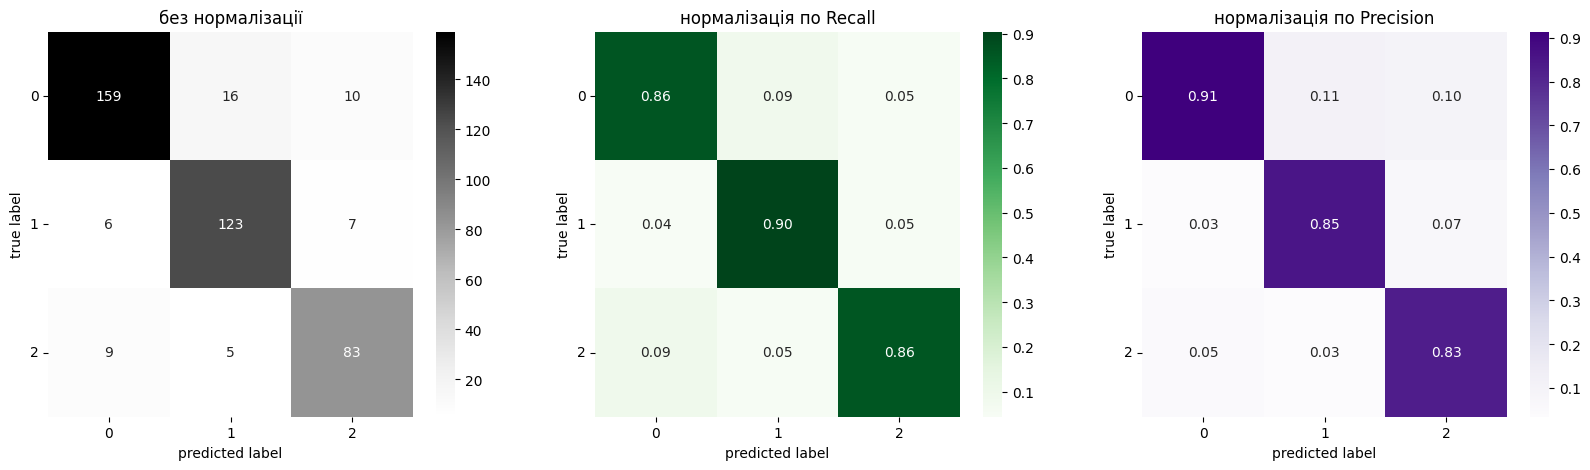

In [50]:
plot_cm(random_ovo.best_estimator_, X_test, y_test)

### OneVsRest

In [51]:
ovr = OneVsRestClassifier(SVC(class_weight='balanced', random_state=90))

param_random_ovr = {
    "estimator__C": [0.1, 1, 10],
    "estimator__kernel": ['linear', 'rbf', 'poly'],
    "estimator__gamma": ['scale', 'auto']
}

In [52]:
random_ovr = RandomizedSearchCV(ovr, param_random_ovr, cv=10, random_state=90, n_jobs=-1, scoring='f1_macro')
random_ovr.fit(X_train, y_train)
print("best OvR params:", random_ovr.best_params_)

best OvR params: {'estimator__kernel': 'rbf', 'estimator__gamma': 'scale', 'estimator__C': 10}


In [53]:
best_ovr = random_ovr.best_estimator_

In [54]:
y_pred_ovr = best_ovr.predict(X_test)

In [55]:
print(classification_report(y_test, y_pred_ovr))

              precision    recall  f1-score   support

air vehicles       0.91      0.88      0.89       185
        tank       0.87      0.90      0.89       136
     weapons       0.84      0.85      0.84        97

    accuracy                           0.88       418
   macro avg       0.87      0.88      0.87       418
weighted avg       0.88      0.88      0.88       418



In [56]:
print(classification_report(y_train, best_ovr.predict(X_train)))

              precision    recall  f1-score   support

air vehicles       0.95      0.94      0.94       738
        tank       0.95      0.93      0.94       542
     weapons       0.89      0.93      0.91       391

    accuracy                           0.93      1671
   macro avg       0.93      0.93      0.93      1671
weighted avg       0.93      0.93      0.93      1671



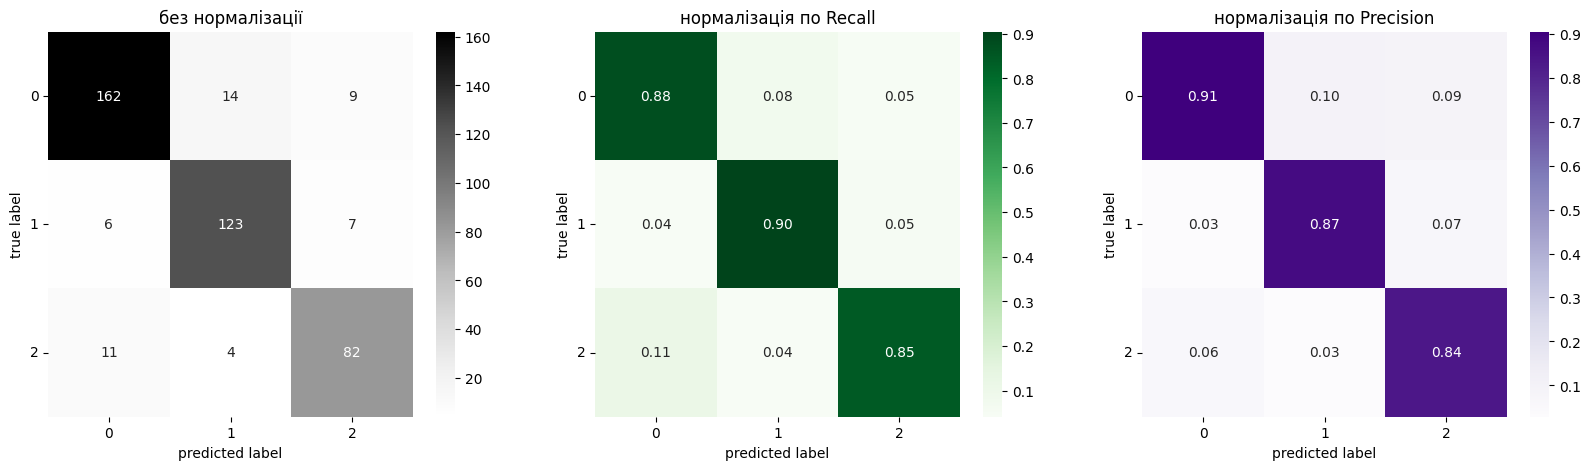

In [57]:
plot_cm(random_ovr.best_estimator_, X_test, y_test)

## boosting

In [58]:
boosting_model = GradientBoostingClassifier(random_state=90)

boosting_model.fit(X_train, y_train)

y_pred_boosting = boosting_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_boosting))
print(classification_report(y_test, y_pred_boosting))

Gradient Boosting Accuracy: 0.84688995215311
              precision    recall  f1-score   support

air vehicles       0.86      0.89      0.88       185
        tank       0.85      0.85      0.85       136
     weapons       0.81      0.76      0.79        97

    accuracy                           0.85       418
   macro avg       0.84      0.83      0.84       418
weighted avg       0.85      0.85      0.85       418



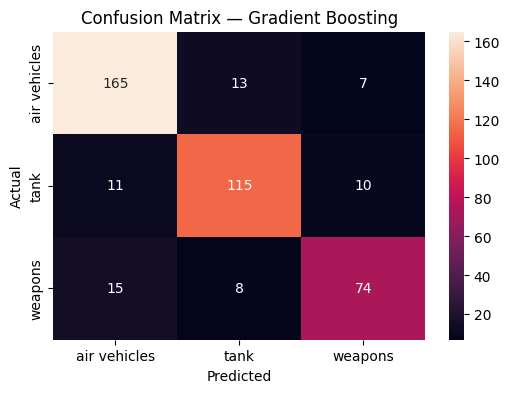

In [59]:
cm = confusion_matrix(y_test, y_pred_boosting)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=boosting_model.classes_,
    yticklabels=boosting_model.classes_
)

plt.title("Confusion Matrix — Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [60]:
param_dist = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

boosting_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=90),
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_macro",
    cv=3,
    random_state=90,
    n_jobs=-1
)

boosting_search.fit(X_train, y_train)

print("Best parameters:", boosting_search.best_params_)
print("Best CV score:", boosting_search.best_score_)

Best parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.2}
Best CV score: 0.8364629985079217


In [61]:
best_boosting_model = boosting_search.best_estimator_

y_pred_best_boosting = best_boosting_model.predict(X_test)

print("Tuned Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_best_boosting))
print(classification_report(y_test, y_pred_best_boosting))

Tuned Gradient Boosting Accuracy: 0.8803827751196173
              precision    recall  f1-score   support

air vehicles       0.88      0.91      0.90       185
        tank       0.91      0.88      0.90       136
     weapons       0.84      0.81      0.83        97

    accuracy                           0.88       418
   macro avg       0.88      0.87      0.87       418
weighted avg       0.88      0.88      0.88       418



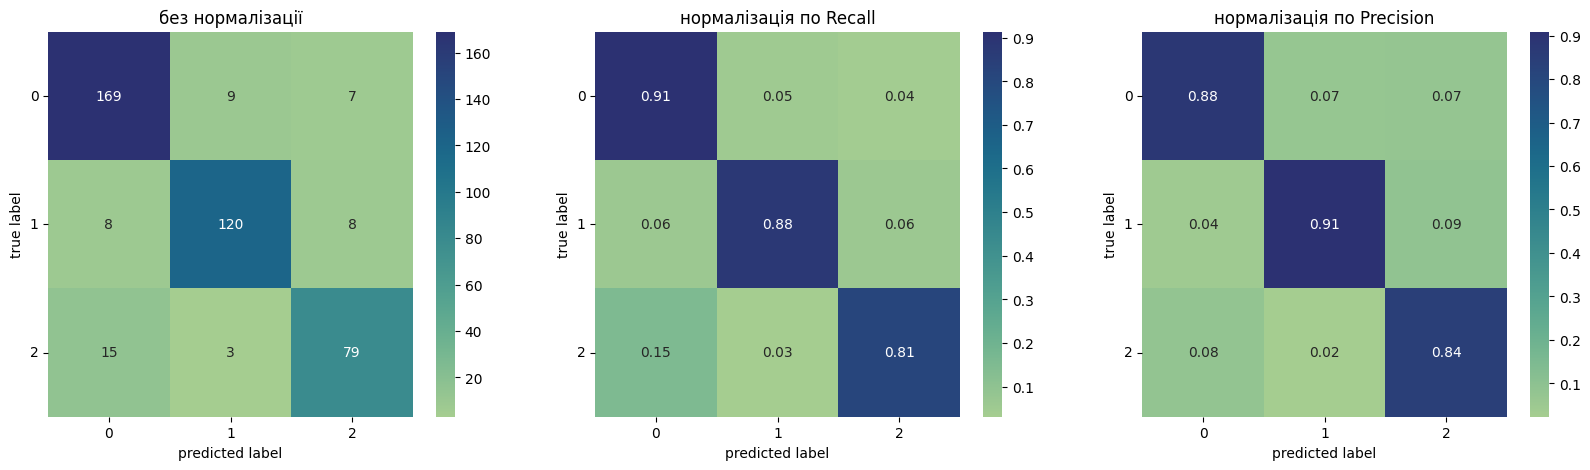

In [147]:
plot_cm(boosting_search.best_estimator_, X_test, y_test)

In [62]:
results_boosting = pd.DataFrame({
    "Model": ["Baseline Gradient Boosting", "Tuned Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_boosting),
        accuracy_score(y_test, y_pred_best_boosting)
    ],
    "F1 macro": [
        classification_report(y_test, y_pred_boosting, output_dict=True)["macro avg"]["f1-score"],
        classification_report(y_test, y_pred_best_boosting, output_dict=True)["macro avg"]["f1-score"]
    ]
})

results_boosting

,Model,Accuracy,F1 macro
0,Baseline Gradient Boosting,0.846890,0.836827
1,Tuned Gradient Boosting,0.880383,0.873100


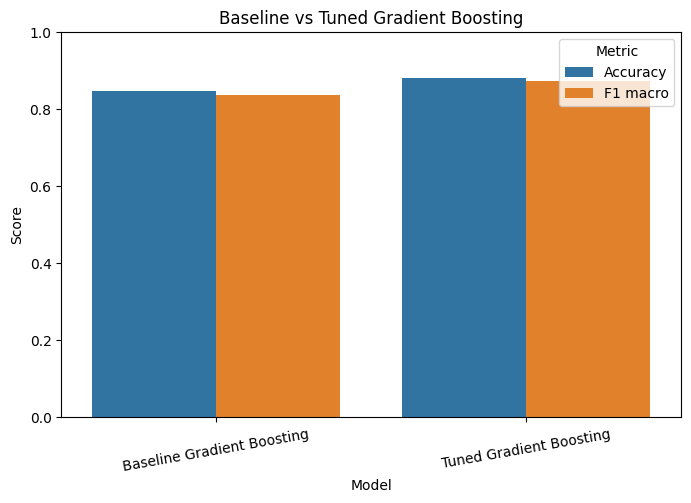

In [63]:
results_boosting_melted = results_boosting.melt(
    id_vars="Model",
    value_vars=["Accuracy", "F1 macro"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=results_boosting_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Baseline vs Tuned Gradient Boosting")
plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=10)
plt.show()

C:\Users\Soroka\AppData\Local\Temp\ipykernel_8016\2655452780.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


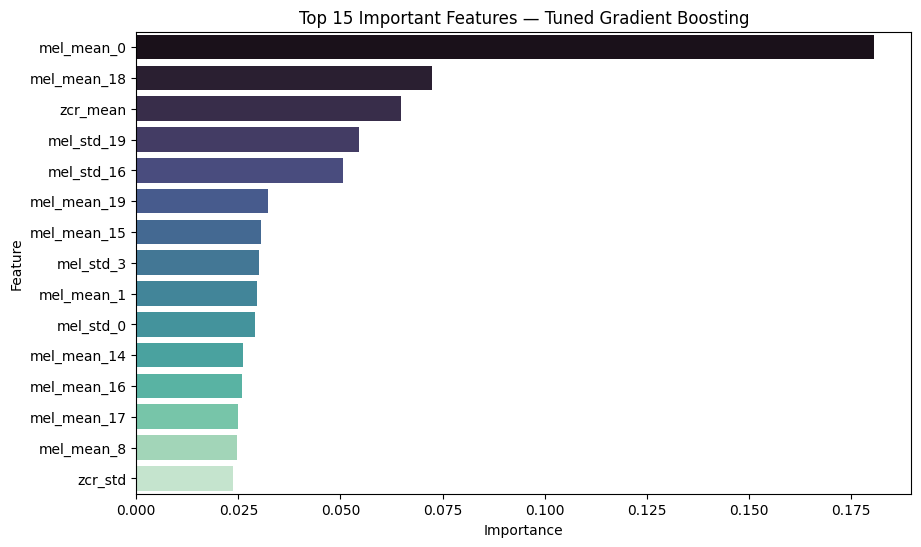

In [141]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_boosting_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    palette='mako'
)

plt.title("Top 15 Important Features — Tuned Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [65]:
report_dict = classification_report(
    y_test,
    y_pred_best_boosting,
    output_dict=True
)

class_metrics = pd.DataFrame(report_dict).T
class_metrics = class_metrics.loc[
    [label for label in best_boosting_model.classes_],
    ["precision", "recall", "f1-score"]
]

class_metrics

,precision,recall,f1-score
air vehicles,0.880208,0.913514,0.896552
tank,0.909091,0.882353,0.895522
weapons,0.840426,0.814433,0.827225


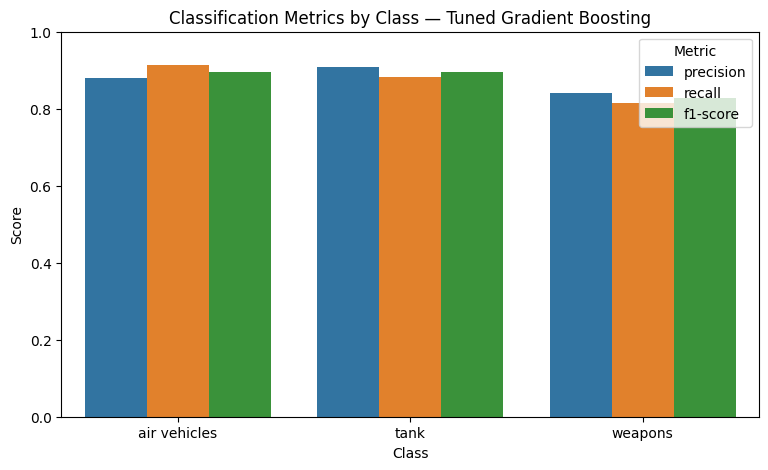

In [66]:
class_metrics_melted = class_metrics.reset_index().melt(
    id_vars="index",
    value_vars=["precision", "recall", "f1-score"],
    var_name="Metric",
    value_name="Score"
)

class_metrics_melted = class_metrics_melted.rename(columns={"index": "Class"})

plt.figure(figsize=(9, 5))
sns.barplot(
    data=class_metrics_melted,
    x="Class",
    y="Score",
    hue="Metric"
)

plt.title("Classification Metrics by Class — Tuned Gradient Boosting")
plt.ylim(0, 1)
plt.xlabel("Class")
plt.ylabel("Score")
plt.show()

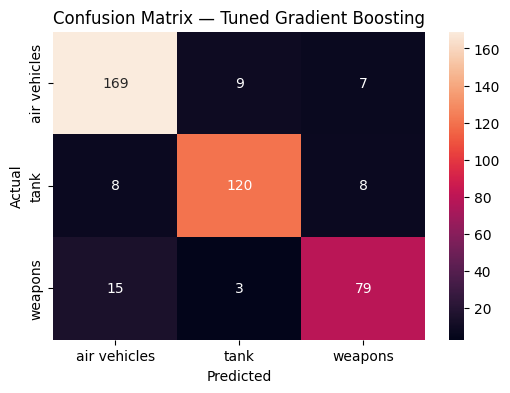

In [67]:
cm = confusion_matrix(y_test, y_pred_best_boosting)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=best_boosting_model.classes_,
    yticklabels=best_boosting_model.classes_
)

plt.title("Confusion Matrix — Tuned Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [70]:
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

models = {
    "logistic_regression": best_logreg,
    "svm_ovo": best_ovo,
    "svm_ovr": best_ovr,
    "gradient_boosting": best_boosting_model
}

predictions = {
    "logistic_regression": y_pred_log,
    "svm_ovo": y_pred_ovo,
    "svm_ovr": y_pred_ovr,
    "gradient_boosting": y_pred_best_boosting
}

results = []

for name in models:
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions[name]),
        "Macro F1": f1_score(y_test, predictions[name], average="macro")
    })

results_df = pd.DataFrame(results)
display(results_df)

best_model_name = results_df.loc[
    results_df["Macro F1"].idxmax(),
    "Model"
]

best_model = models[best_model_name]

print("Найкраща модель:", best_model_name)
print("Macro F1:", results_df["Macro F1"].max())

joblib.dump(best_model, "model.pkl")

,Model,Accuracy,Macro F1
0,logistic_regression,0.751196,0.748192
1,svm_ovo,0.873206,0.869002
2,svm_ovr,0.877990,0.873074
3,gradient_boosting,0.880383,0.873100


Найкраща модель: gradient_boosting
Macro F1: 0.8730997476958949


['model.pkl']

In [71]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']